In [2]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm
import json
import seaborn as sns
import plot_utils
import glob
from scipy.optimize import curve_fit
from scipy import special

In [3]:
sns.set_palette("viridis")

In [4]:
#select colors from sns palette
colors = sns.color_palette("viridis", n_colors=10)
print(colors)

[(0.283072, 0.130895, 0.449241), (0.262138, 0.242286, 0.520837), (0.220057, 0.343307, 0.549413), (0.177423, 0.437527, 0.557565), (0.143343, 0.522773, 0.556295), (0.119512, 0.607464, 0.540218), (0.166383, 0.690856, 0.496502), (0.319809, 0.770914, 0.411152), (0.525776, 0.833491, 0.288127), (0.762373, 0.876424, 0.137064)]


In [5]:
temperatures = [-40,-30, -20,-10, 0]

In [6]:
devices = ['LMG405', 'LMG450', 'LMG365', 'LMG520', 'KAPU465', 'KAPU405']

In [7]:
device = 'LMG405'
pw = 54000
coarse_fine = '2-20'
mode = 'default'
batch = 'batch2'
pocam = 26
hemisphere = 52

In [8]:
def gaussian(x, mean, sigma):
    return 1 / (np.sqrt(2 * np.pi) * sigma) * np.exp(-0.5 * ((x - mean) / sigma) ** 2)


def skewing_erf(x, mean, sigma, alpha):
    return 0.5 * (1 + special.erf(alpha * (x - mean) / (np.sqrt(2) * sigma)))


def skewed_gaussian(x, mean, sigma, scaling, alpha):
    """Skewed Gaussian: scaled pdf of a skew-normal distribution."""
    return scaling * 2 * gaussian(x, mean, sigma) * skewing_erf(x, mean, sigma, alpha)

def skewed_double_gaussian(x, mean, sigma, scaling, alpha,
                           mean_2, sigma_2, scaling_2):
    """Skewed Gaussian main peak + plain Gaussian secondary peak."""
    return (skewed_gaussian(x, mean, sigma, scaling, alpha)
            + scaling_2 * gaussian(x, mean_2, sigma_2))

In [9]:
coarse_fine = ['1-10', '1-20', '1-40', '2-20']

In [10]:
T = -20

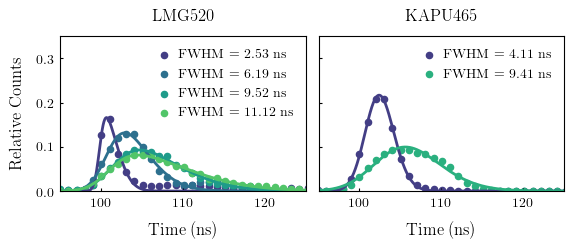

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import json

# Define skewed Gaussian and FWHM computation
def skewed_gaussian(x, mean, sigma, scaling, alpha):
    """Skewed Gaussian: scaled pdf of a skew-normal distribution."""
    return scaling * 2 * gaussian(x, mean, sigma) * skewing_erf(x, mean, sigma, alpha)

def compute_fwhm_skewed_gaussian(mu, sigma, amp, alpha):
    # Numerically compute FWHM for the fitted skewed Gaussian
    x = np.linspace(mu - 5*sigma, mu + 5*sigma, 1000)
    y = skewed_gaussian(x, mu, sigma, amp, alpha)
    half_max = np.max(y) / 2
    indices = np.where(y >= half_max)[0]
    if len(indices) > 1:
        fwhm = x[indices[-1]] - x[indices[0]]
    else:
        fwhm = np.nan
    return fwhm

fig, (ax1,ax2) = plt.subplots(1,2, figsize=plot_utils.set_size('text', fraction=1, subplots=(1,2)), sharey=True)
device1 = "LMG520"
for c_f, color in zip(coarse_fine, [colors[1], colors[3], colors[5], colors[7]]):
    path = f'../output/{batch}/pocam_{pocam:03d}/hem_{hemisphere}/{device1}/tdc_{pw:.0f}_{T}C_{c_f}.json'
    with open(path, 'r') as f:
        data = json.load(f)
    x_values = np.linspace(data['meas_data'][0]['x_min'], data['meas_data'][0]['x_max'], data['meas_data'][0]['n_bins'])
    x_fit = np.linspace(data['meas_data'][0]['fit_x_min'], data['meas_data'][0]['fit_x_max'], data['meas_data'][0]['fit_n_bins'])
    counts = data['meas_data'][0]['y_values']
    mask = np.array(counts) > 0.03
    offset_data = x_values[mask][0] - 100
    x_values_corrected = x_values - offset_data
    fit, cov = curve_fit(skewed_gaussian, x_values_corrected, counts, p0=[np.mean(x_values_corrected), np.std(x_values_corrected), max(counts), 0])
    fwhm_fit = compute_fwhm_skewed_gaussian(*fit)
    ax1.scatter(x_values - offset_data, counts, s=20, color=color, label=f'FWHM = {fwhm_fit:.2f} ns')
    ax1.plot(x_fit, skewed_gaussian(x_fit, *fit), color=color)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Relative Counts')
ax1.set_xlim(95, 125)
ax1.set_ylim(0, 0.35)
ax1.legend()
ax1.set_title(f'{device1}', size=12, y=1.2)

device2 = "KAPU465"
for mode, color in zip(['fast', 'default'], [colors[1], colors[6]]):
    path = f'../output/{batch}/pocam_{pocam:03d}/hem_{hemisphere}/{device2}/tdc_{pw:.0f}_{T}C_{mode}.json'
    with open(path, 'r') as f:
        data = json.load(f)
    x_values = np.linspace(data['meas_data'][0]['x_min'], data['meas_data'][0]['x_max'], data['meas_data'][0]['n_bins'])
    x_fit = np.linspace(data['meas_data'][0]['fit_x_min'], data['meas_data'][0]['fit_x_max'], data['meas_data'][0]['fit_n_bins'])
    counts = data['meas_data'][0]['y_values']
    mask = np.array(counts) > 0.03
    offset_data = x_values[mask][0] - 100
    x_values_corrected = x_values - offset_data
    fit, cov = curve_fit(skewed_gaussian, x_values_corrected, counts, p0=[np.mean(x_values_corrected), np.std(x_values_corrected), max(counts), 0])
    fwhm_fit = compute_fwhm_skewed_gaussian(*fit)
    ax2.scatter(x_values - offset_data, counts, s=20, color=color, label=f'FWHM = {fwhm_fit:.2f} ns')
    ax2.plot(x_fit, skewed_gaussian(x_fit, *fit), color=color)

ax2.set_xlabel('Time (ns)')
ax2.set_xlim(95, 125)
ax2.legend()
ax2.set_title(f'{device2}', size=12, y=1.2)
plt.subplots_adjust(wspace=0.05)
plt.savefig(f'plots/png/{device1}_{device2}_pocam_{pocam}_hem_{hemisphere}_tdc_{pw:.0f}_{T}C_skewed_gaussian_fit.png', dpi=300)

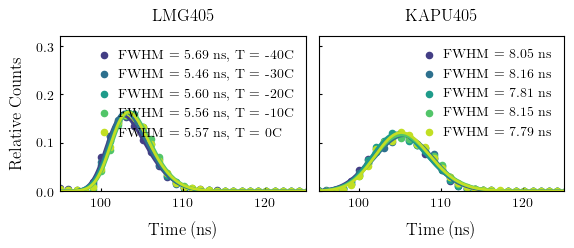

In [20]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=plot_utils.set_size('text', fraction=1, subplots=(1,2)), sharey = True)
device1 = "LMG405"
c_f = '1-20'
temperatures = [-40,-30, -20,-10, 0]
for T, color in zip(temperatures, [colors[1], colors[3], colors[5], colors[7], colors[9]]):
    path = f'../output/{batch}/pocam_{pocam:03d}/hem_{hemisphere}/{device1}/tdc_{pw:.0f}_{T}C_{c_f}.json'
    with open(path, 'r') as f:
        data = json.load(f)
    fwhm = data['meas_data'][1]['value']
    x_values = np.linspace(data['meas_data'][0]['x_min'], data['meas_data'][0]['x_max'], data['meas_data'][0]['n_bins'])
    x_fit = np.linspace(data['meas_data'][0]['fit_x_min'], data['meas_data'][0]['fit_x_max'], data['meas_data'][0]['fit_n_bins'])
    #fit a skewed gaussian to the data in the x-fit range
    counts = data['meas_data'][0]['y_values']
    mask = np.array(counts) > 0.03
    offset_data = x_values[mask][0] -100
    x_values_corrected = x_values - offset_data
    fit, cov = curve_fit(skewed_gaussian, x_values_corrected, data['meas_data'][0]['y_values'], p0=[np.mean(x_values_corrected), np.std(x_values_corrected), max(data['meas_data'][0]['y_values']), 0])
    #plot fit and data
    ax1.scatter(x_values-offset_data, data['meas_data'][0]['y_values'],s= 20,color = color, label = f'FWHM = {fwhm:.2f} ns, T = {T}C')
    # ax.step(x_values-offset_data, data['meas_data'][0]['y_values'], where ='mid',label = f'{c_f}')
    ax1.plot(x_fit, skewed_gaussian(x_fit, *fit), color= color)
    # plt.plot(x_fit-offset_fit, data['meas_data'][0]['fit_y_values'])

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Relative Counts')
ax1.set_xlim(95,125)
ax1.set_ylim(0,0.32)
ax1.legend()
ax1.set_title(f'{device1}', size = 12, y = 1.2)

device2 = "KAPU405"
mode = 'default'
for T, color in zip(temperatures, [colors[1], colors[3], colors[5], colors[7], colors[9]]):
    path = f'../output/{batch}/pocam_{pocam:03d}/hem_{hemisphere}/{device2}/tdc_{pw:.0f}_{T}C_{mode}.json'
    with open(path, 'r') as f:
        data = json.load(f)
    fwhm = data['meas_data'][1]['value']
    x_values = np.linspace(data['meas_data'][0]['x_min'], data['meas_data'][0]['x_max'], data['meas_data'][0]['n_bins'])
    x_fit = np.linspace(data['meas_data'][0]['fit_x_min'], data['meas_data'][0]['fit_x_max'], data['meas_data'][0]['fit_n_bins'])
    #fit a skewed gaussian to the data in the x-fit range
    counts = data['meas_data'][0]['y_values']
    mask = np.array(counts) > 0.03
    offset_data = x_values[mask][0] -100
    x_values_corrected = x_values - offset_data
    fit, cov = curve_fit(skewed_gaussian, x_values_corrected, data['meas_data'][0]['y_values'], p0=[np.mean(x_values_corrected), np.std(x_values_corrected), max(data['meas_data'][0]['y_values']), 0])
    #plot fit and data
    ax2.scatter(x_values-offset_data, data['meas_data'][0]['y_values'],s= 20,color = color, label = f'FWHM = {fwhm:.2f} ns')
    # ax.step(x_values-offset_data, data['meas_data'][0]['y_values'], where ='mid',label = f'{c_f}')
    ax2.plot(x_fit, skewed_gaussian(x_fit, *fit), color = color)

ax2.set_xlabel('Time (ns)')
ax2.set_xlim(95,125)
ax2.legend()
ax2.set_title(f'{device2}', size = 12, y = 1.2)
plt.subplots_adjust(wspace=0.05)
plt.savefig(f'plots/png/{device1}_{device2}_pocam_{pocam}_hem_{hemisphere}_tdc_{pw:.0f}_check_Temperatures_skewed_gaussian_fit.png', dpi=300)

In [13]:
fwhm_dict_patrick = {}
fwhm_dict_elena = {}

for device in devices: 
    for T in temperatures:
        path = f'../output/batch*/pocam_*/hem_*/{device}/tdc_54000_{T}C_1-20.json'
        filelist = glob.glob(path)
        fwhm_dict_elena[f'{device}_{T}'] = []
        fwhm_dict_patrick[f'{device}_{T}'] = []
        for f in filelist:
            with open(f, 'r') as file:
                data = json.load(file)

            x_values = np.linspace(data['meas_data'][0]['x_min'], data['meas_data'][0]['x_max'], data['meas_data'][0]['n_bins'])
            x_fit = np.linspace(data['meas_data'][0]['fit_x_min'], data['meas_data'][0]['fit_x_max'], data['meas_data'][0]['fit_n_bins'])
            counts = data['meas_data'][0]['y_values']
            mask = np.array(counts) > 0.03
            offset_data = x_values[mask][0] - 100
            x_values_corrected = x_values - offset_data
            try:
                fit, cov = curve_fit(
                    skewed_gaussian, 
                    x_values_corrected, 
                    counts, 
                    p0=[np.mean(x_values_corrected), np.std(x_values_corrected), max(counts), 0]
                )
                fwhm_fit = compute_fwhm_skewed_gaussian(*fit)
                fwhm_dict_elena[f'{device}_{T}'].append(fwhm_fit)
                fwhm_dict_patrick[f'{device}_{T}'].append(data['meas_data'][1]['value'])
            except Exception:
                continue


In [15]:
LMG_devices = ['LMG405', 'LMG450', 'LMG365', 'LMG520']
KAPU_devices = ['KAPU465', 'KAPU405']

In [20]:
fwhm_dict_patrick = {}
fwhm_dict_elena = {}

for device in LMG_devices: 
    for c_f in coarse_fine:
        path = f'../output/batch*/pocam_*/hem_*/{device}/tdc_54000_*C_{c_f}.json'
        filelist = glob.glob(path)
        fwhm_dict_elena[f'{device}_{c_f}'] = []
        fwhm_dict_patrick[f'{device}_{c_f}'] = []
        for f in filelist:
            with open(f, 'r') as file:
                data = json.load(file)

            x_values = np.linspace(data['meas_data'][0]['x_min'], data['meas_data'][0]['x_max'], data['meas_data'][0]['n_bins'])
            counts = data['meas_data'][0]['y_values']
            mask = np.array(counts) > 0.03
            if np.sum(mask) == 0:
                continue  # Skip if no counts > 0.03
            offset_data = x_values[mask][0] - 100
            x_values_corrected = x_values - offset_data
            try:
                fit, cov = curve_fit(
                    skewed_gaussian, 
                    x_values_corrected, 
                    counts, 
                    p0=[np.mean(x_values_corrected), np.std(x_values_corrected), max(counts), 0]
                )
                fwhm_fit = compute_fwhm_skewed_gaussian(*fit)
                fwhm_dict_elena[f'{device}_{c_f}'].append(fwhm_fit)
                fwhm_dict_patrick[f'{device}_{c_f}'].append(data['meas_data'][1]['value'])
            except Exception:
                continue

for device in KAPU_devices:
    for mode in ['fast', 'default']:
        path = f'../output/batch*/pocam_*/hem_*/{device}/tdc_54000_*C_{mode}.json'
        filelist = glob.glob(path)
        fwhm_dict_elena[f'{device}_{mode}'] = []
        fwhm_dict_patrick[f'{device}_{mode}'] = []
        for f in filelist:
            with open(f, 'r') as file:
                data = json.load(file)

            x_values = np.linspace(data['meas_data'][0]['x_min'], data['meas_data'][0]['x_max'], data['meas_data'][0]['n_bins'])
            counts = data['meas_data'][0]['y_values']
            mask = np.array(counts) > 0.03
            if np.sum(mask) == 0:
                continue  # Skip if no counts > 0.03
            offset_data = x_values[mask][0] - 100
            x_values_corrected = x_values - offset_data
            try:
                fit, cov = curve_fit(
                    skewed_gaussian, 
                    x_values_corrected, 
                    counts, 
                    p0=[np.mean(x_values_corrected), np.std(x_values_corrected), max(counts), 0]
                )
                fwhm_fit = compute_fwhm_skewed_gaussian(*fit)
                fwhm_dict_elena[f'{device}_{mode}'].append(fwhm_fit)
                fwhm_dict_patrick[f'{device}_{mode}'].append(data['meas_data'][1]['value'])
            except Exception:
                continue

../output/batch2/pocam_023/hem_45/LMG405/tdc_54000_-10C_1-10.json
../output/batch2/pocam_023/hem_45/LMG405/tdc_54000_-40C_1-10.json
../output/batch2/pocam_023/hem_45/LMG405/tdc_54000_0C_1-10.json
../output/batch2/pocam_023/hem_45/LMG405/tdc_54000_-20C_1-10.json
../output/batch2/pocam_023/hem_45/LMG405/tdc_54000_-30C_1-10.json
../output/batch2/pocam_023/hem_46/LMG405/tdc_54000_-10C_1-10.json
../output/batch2/pocam_023/hem_46/LMG405/tdc_54000_-40C_1-10.json
../output/batch2/pocam_023/hem_46/LMG405/tdc_54000_0C_1-10.json
../output/batch2/pocam_023/hem_46/LMG405/tdc_54000_-20C_1-10.json
../output/batch2/pocam_023/hem_46/LMG405/tdc_54000_-30C_1-10.json
../output/batch2/pocam_017/hem_34/LMG405/tdc_54000_-10C_1-10.json
../output/batch2/pocam_017/hem_34/LMG405/tdc_54000_-40C_1-10.json
../output/batch2/pocam_017/hem_34/LMG405/tdc_54000_0C_1-10.json
../output/batch2/pocam_017/hem_34/LMG405/tdc_54000_-20C_1-10.json
../output/batch2/pocam_017/hem_34/LMG405/tdc_54000_-30C_1-10.json
../output/batch2

In [22]:
fwhm_dict_elena.keys()

dict_keys(['LMG405_1-10', 'LMG405_1-20', 'LMG405_1-40', 'LMG405_2-20', 'LMG450_1-10', 'LMG450_1-20', 'LMG450_1-40', 'LMG450_2-20', 'LMG365_1-10', 'LMG365_1-20', 'LMG365_1-40', 'LMG365_2-20', 'LMG520_1-10', 'LMG520_1-20', 'LMG520_1-40', 'LMG520_2-20', 'KAPU465_fast', 'KAPU465_default', 'KAPU405_fast', 'KAPU405_default'])

In [27]:
Temperatures = [-40,-30, -20, -10, 0, 25]

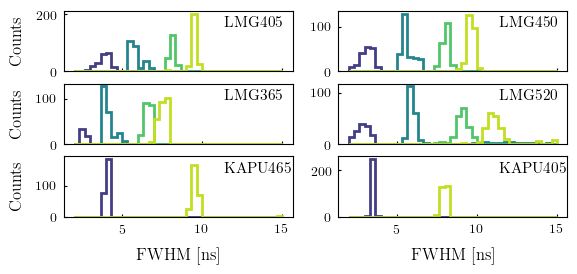

In [38]:
fig, axes = plt.subplots(3,2, figsize=plot_utils.set_size('text', fraction=1, subplots=(2,3)), sharex = True)

for i, ax in enumerate(axes.flat):
    device = devices[i]
    bins = np.linspace(2, 15, 40)
    if device in LMG_devices:
        for c_f, color in zip(coarse_fine, [colors[1], colors[4], colors[7], colors[9]]):
            fwhm_elena = fwhm_dict_elena[f'{device}_{c_f}']
            fwhm_patrick = fwhm_dict_patrick[f'{device}_{c_f}']
            ax.hist(fwhm_elena, bins = bins,color=color, histtype = 'step', lw = 2 ,label=f'{c_f}')
    if device in KAPU_devices:
        for c_f, color in zip(['fast', 'default'], [colors[1], colors[9]]):
            fwhm_elena = fwhm_dict_elena[f'{device}_{c_f}']
            fwhm_patrick = fwhm_dict_patrick[f'{device}_{c_f}']
            ax.hist(fwhm_elena, bins = bins,color=color, histtype = 'step', lw = 2 ,label=f'{c_f}')
    ax.text(0.7, 0.72, f'{device}',  transform=ax.transAxes, fontsize=11)
    if np.isin(i, [4,5]):
        ax.set_xlabel('FWHM [ns]')
    
    if i == 0 or i == 2 or i == 4:
        ax.set_ylabel('Counts')

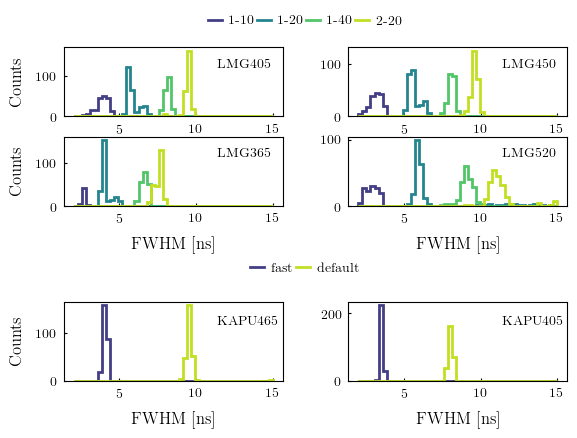

In [57]:
from collections import OrderedDict

fig = plt.figure(figsize=plot_utils.set_size('text', fraction=1, ratio=1, subplots=(2,3)))

gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.8)
gs_top = gs[0].subgridspec(2, 2, hspace=0.3, wspace=0.3)
gs_bot = gs[1].subgridspec(1, 2, wspace=0.3)

axes_top = [fig.add_subplot(gs_top[i, j]) for i in range(2) for j in range(2)]
axes_bot = [fig.add_subplot(gs_bot[0, j]) for j in range(2)]

def unique_legend(handles, labels):
    od = OrderedDict()
    for h, l in zip(handles, labels):
        od[l] = h
    return list(od.values()), list(od.keys())

bins = np.linspace(2, 15, 50)

# --- Top 4: LMG devices (coarse-fine) ---
legend_handles_1 = []
legend_labels_1 = []

for i, (ax, device) in enumerate(zip(axes_top, LMG_devices)):
    for c_f, color in zip(coarse_fine, [colors[1], colors[4], colors[7], colors[9]]):
        fwhm_elena = fwhm_dict_elena[f'{device}_{c_f}']
        ax.hist(fwhm_elena, bins=bins, color=color, histtype='step', lw=2, label=f'{c_f}')
        legend_handles_1.append(plt.Line2D([0], [0], color=color, lw=2))
        legend_labels_1.append(f'{c_f}')
    ax.text(0.7, 0.7, f'{device}', transform=ax.transAxes, fontsize=10)
    if i >= 2:
        ax.set_xlabel('FWHM [ns]')
    if i in [0, 2]:
        ax.set_ylabel('Counts')

# share x across top axes
for ax in axes_top:
    ax.sharex(axes_top[0])

# --- Bottom 2: KAPU devices (default/fast) ---
legend_handles_2 = []
legend_labels_2 = []

for j, (ax, device) in enumerate(zip(axes_bot, KAPU_devices)):
    for c_f, color in zip(['fast', 'default'], [colors[1], colors[9]]):
        fwhm_elena = fwhm_dict_elena[f'{device}_{c_f}']
        ax.hist(fwhm_elena, bins=bins, color=color, histtype='step', lw=2, label=f'{c_f}')
        legend_handles_2.append(plt.Line2D([0], [0], color=color, lw=2))
        legend_labels_2.append(f'{c_f}')
    ax.text(0.7, 0.7, f'{device}', transform=ax.transAxes, fontsize=10)
    ax.set_xlabel('FWHM [ns]')
    if j == 0:
        ax.set_ylabel('Counts')

for ax in axes_bot:
    ax.sharex(axes_bot[0])

legend_handles_1, legend_labels_1 = unique_legend(legend_handles_1, legend_labels_1)
legend_handles_2, legend_labels_2 = unique_legend(legend_handles_2, legend_labels_2)

# Legend for top group
axes_top[0].legend(
    legend_handles_1, legend_labels_1, 
    loc='upper center', bbox_to_anchor=(1.1, 1.65), ncol=len(legend_labels_1), frameon=False
)

# Legend for bottom group
axes_bot[0].legend(
    legend_handles_2, legend_labels_2, 
    loc='upper center', bbox_to_anchor=(1.1, 1.65), ncol=len(legend_labels_2), frameon=False
)

plt.savefig(f'plots/png/All_Devices_FWHM_histograms.png', dpi=300, bbox_inches='tight')
plt.savefig(f'plots/pdf/All_Devices_FWHM_histograms.pdf', dpi=300, bbox_inches='tight')